### Exploratory Data Analysis and Feature Engineering

1. Import Libraries
2. Load Data
3. Data Dictionary / Target Definition
4. Basic Data Quality Checks
5. Missing Values
6. Class Imbalance
7. Correlation Analysis
8. Distribution Plots
9. Default Rates by Feature
10. Outlier Detection
11. Feature Engineering Ideas
12. Save Cleaned Dataset


In [47]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set(style="whitegrid", context="notebook")

In [48]:
# Update the path to your dataset
data_path = "data/credit_risk.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (5000, 12)


,age,edu,gender,housing,income,job_occupation,past_bad_credit,married,loan_amount,debt_to_income,credit_history_years,default_label
0,25,high_school,male,mortgage,38529.33,self_employed,0,0,9178.73,0.73,10.4,0
1,59,bachelor,male,rent,NaN,salary_worker,0,0,5594.13,0.26,6.4,0
2,53,phd,female,rent,12746.85,salary_worker,0,0,3480.77,0.45,2.5,0
3,42,master,female,mortgage,39871.71,retired,0,0,8020.42,0.43,4.0,0
4,42,high_school,male,own,36575.92,public_sector,0,0,5432.12,0.04,12.6,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   edu                   4862 non-null   object 
 2   gender                5000 non-null   object 
 3   housing               5000 non-null   object 
 4   income                4768 non-null   float64
 5   job_occupation        4806 non-null   object 
 6   past_bad_credit       5000 non-null   int64  
 7   married               5000 non-null   int64  
 8   loan_amount           5000 non-null   float64
 9   debt_to_income        4899 non-null   float64
 10  credit_history_years  4853 non-null   float64
 11  default_label         5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


None

In [49]:
# Column names and types
audit = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100)
}).sort_values("missing_pct", ascending=False)

display(audit)

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

,column,dtype,missing_count,missing_pct
4,income,float64,232,4.64
5,job_occupation,object,194,3.88
10,credit_history_years,float64,147,2.94
1,edu,object,138,2.76
9,debt_to_income,float64,101,2.02
0,age,int64,0,0.00
2,gender,object,0,0.00
3,housing,object,0,0.00
6,past_bad_credit,int64,0,0.00
7,married,int64,0,0.00


Duplicate rows: 0


#### Target validation

default_label
0    4680
1     320
Name: count, dtype: int64
default_label
0    0.936
1    0.064
Name: proportion, dtype: float64


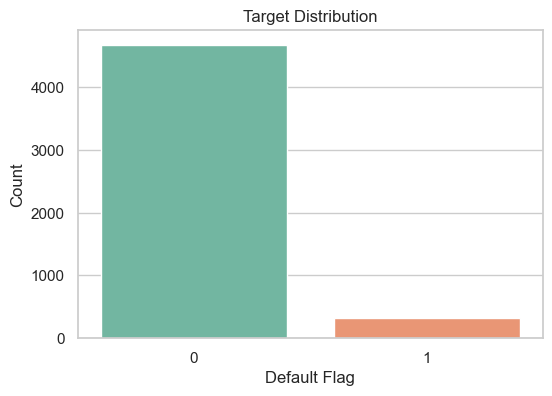

In [50]:
# Change target name if needed
TARGET_COL = "default_label"

print(df[TARGET_COL].value_counts(dropna=False))
print(df[TARGET_COL].value_counts(normalize=True, dropna=False).round(4))

plt.figure(figsize=(6,4))
sns.countplot(x=TARGET_COL, data=df, palette="Set2")
plt.title("Target Distribution")
plt.xlabel("Default Flag")
plt.ylabel("Count")
plt.show()

#### Missing values analysis

,missing_count,missing_pct
income,232,4.64
job_occupation,194,3.88
credit_history_years,147,2.94
edu,138,2.76
debt_to_income,101,2.02


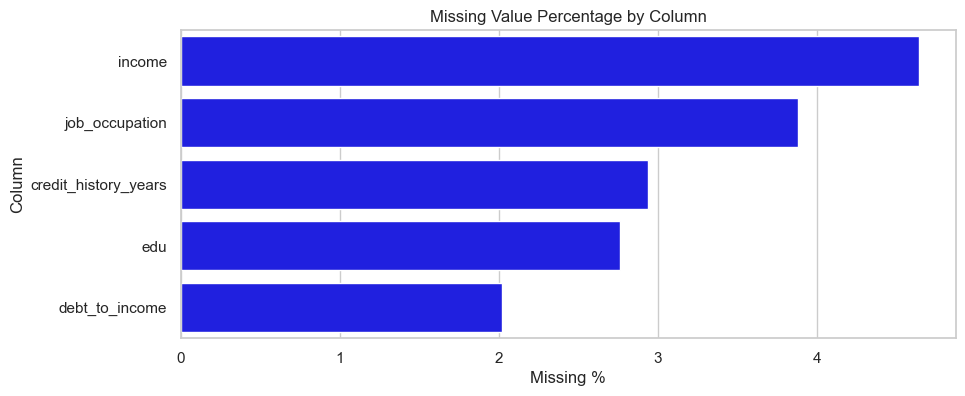

In [51]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
      .sort_values("missing_pct", ascending=False)
)

display(missing[missing["missing_count"] > 0])

plt.figure(figsize=(10, max(4, 0.25 * len(missing[missing["missing_count"] > 0]))))
sns.barplot(
    x="missing_pct",
    y=missing[missing["missing_count"] > 0].index,
    data=missing[missing["missing_count"] > 0].reset_index(),
    color="blue"
)
plt.title("Missing Value Percentage by Column")
plt.xlabel("Missing %")
plt.ylabel("Column")
plt.show()

#### Class imbalance

Default rate: 0.0640
default_label
0    4680
1     320
Name: count, dtype: int64


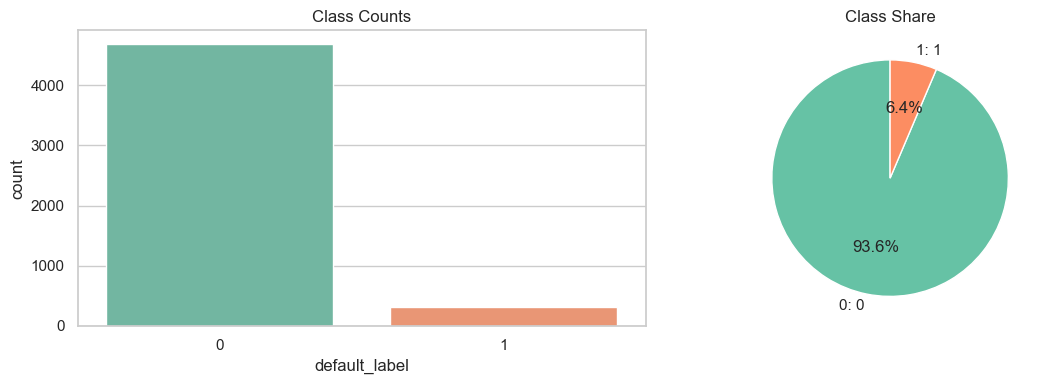

In [52]:
default_rate = df[TARGET_COL].mean()
counts = df[TARGET_COL].value_counts()

print(f"Default rate: {default_rate:.4f}")
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=TARGET_COL, data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Class Counts")

axes[1].pie(counts.values, labels=[f"0: {counts.index[0]}", f"1: {counts.index[1]}"], autopct="%1.1f%%",
            startangle=90, colors=["#66c2a5", "#fc8d62"])
axes[1].set_title("Class Share")

plt.tight_layout()
plt.show()

### Numeric and categorical split

In [53]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if TARGET_COL in num_cols:
    num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols:
    cat_cols.remove(TARGET_COL)

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 7
Categorical columns: 4


#### Correlation analysis

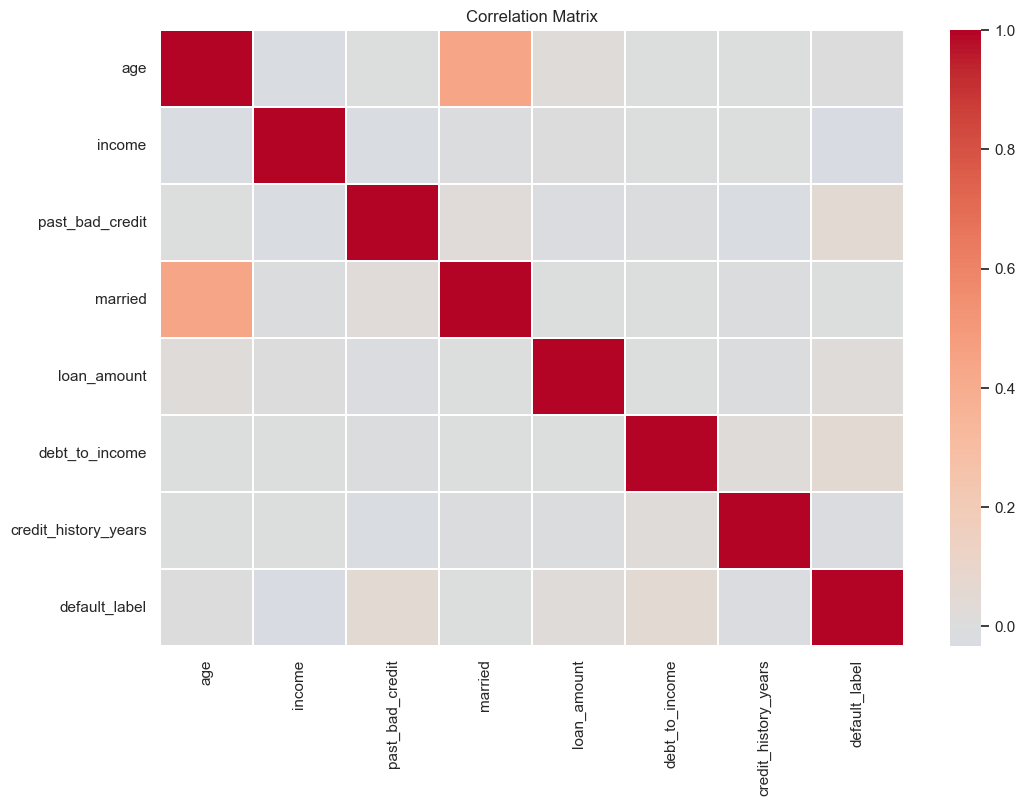

,feature_1,feature_2,abs_corr


In [54]:
corr_cols = [c for c in num_cols if df[c].nunique(dropna=True) > 1]

corr = df[corr_cols + [TARGET_COL]].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Matrix")
plt.show()

# High correlation pairs
threshold = 0.80
high_corr_pairs = []
corr_abs = corr.abs()

for i, col1 in enumerate(corr_abs.columns):
    for col2 in corr_abs.columns[i+1:]:
        if corr_abs.loc[col1, col2] >= threshold and col1 != TARGET_COL and col2 != TARGET_COL:
            high_corr_pairs.append((col1, col2, corr_abs.loc[col1, col2]))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "abs_corr"])
display(high_corr_df.sort_values("abs_corr", ascending=False))

##### Distribution plots

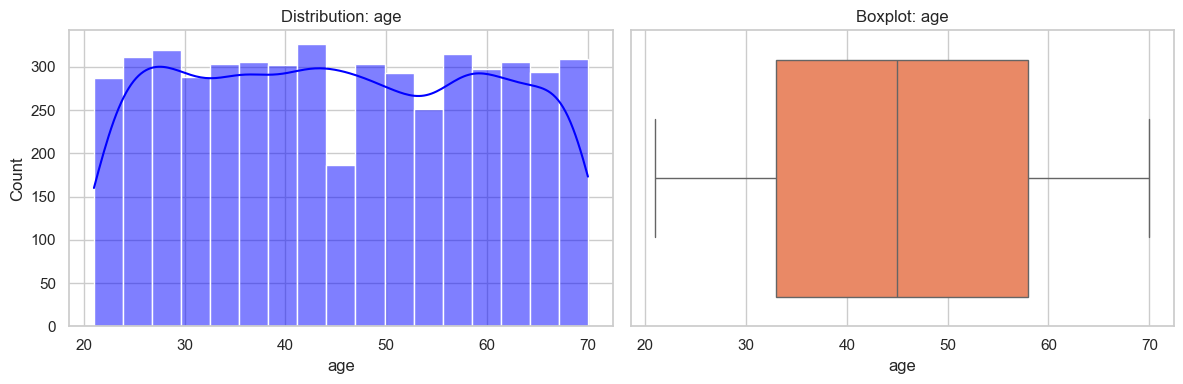

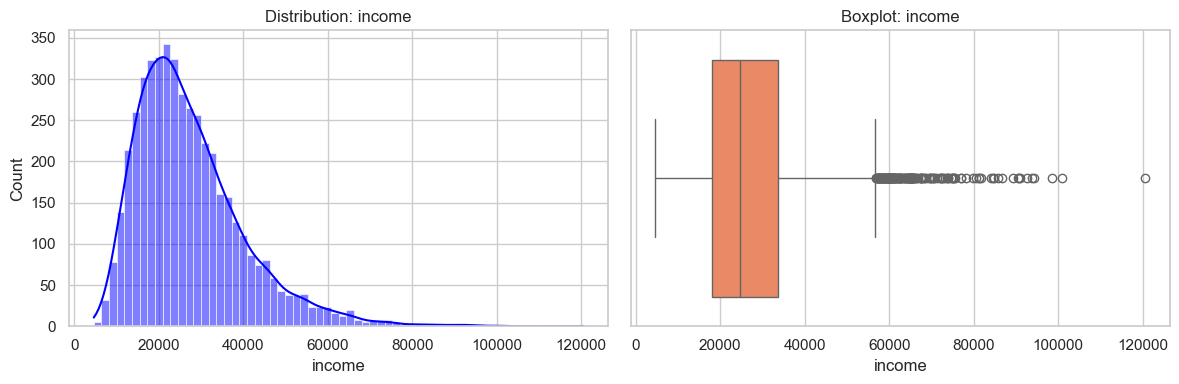

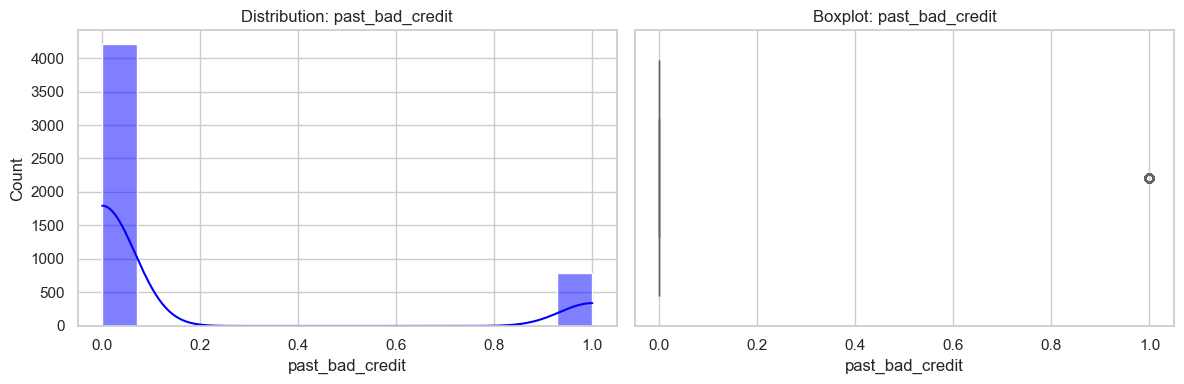

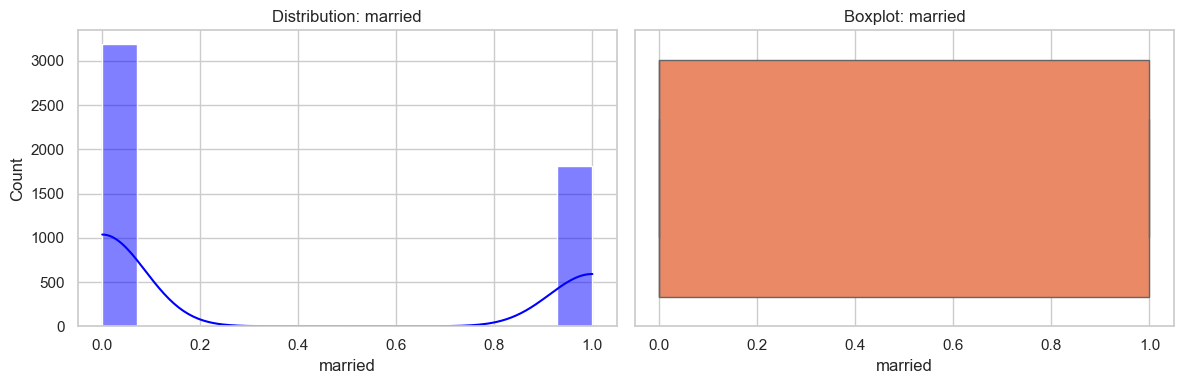

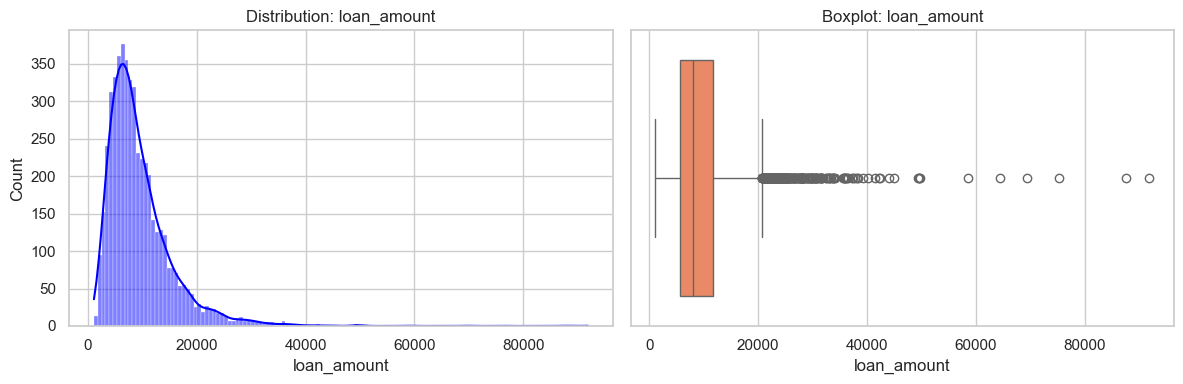

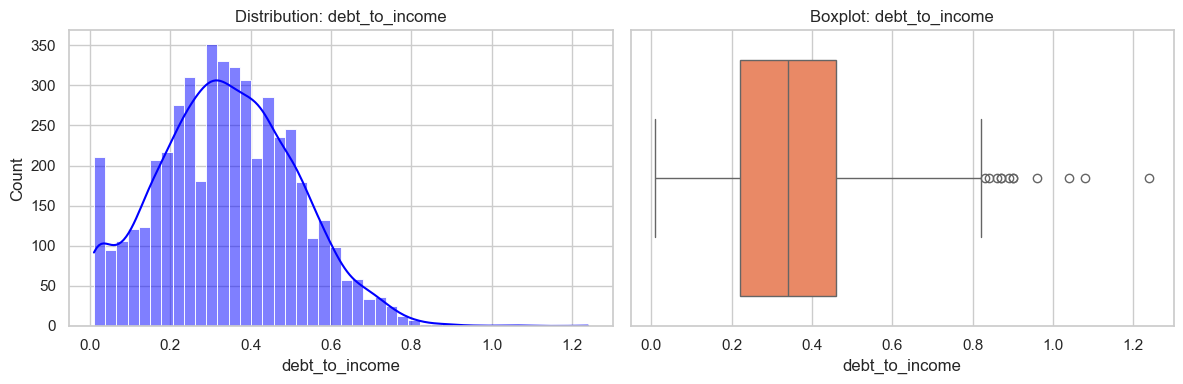

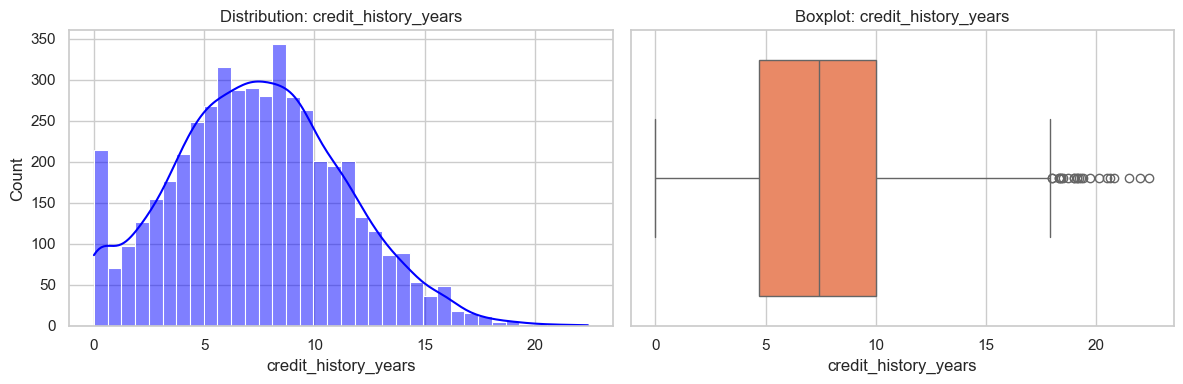

In [55]:
# Numeric distributions
sample_num = num_cols[:12]  # adjust as needed

for col in sample_num:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0], color="blue")
    axes[0].set_title(f"Distribution: {col}")

    sns.boxplot(x=df[col], ax=axes[1], color="coral")
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

### Categorical distributions

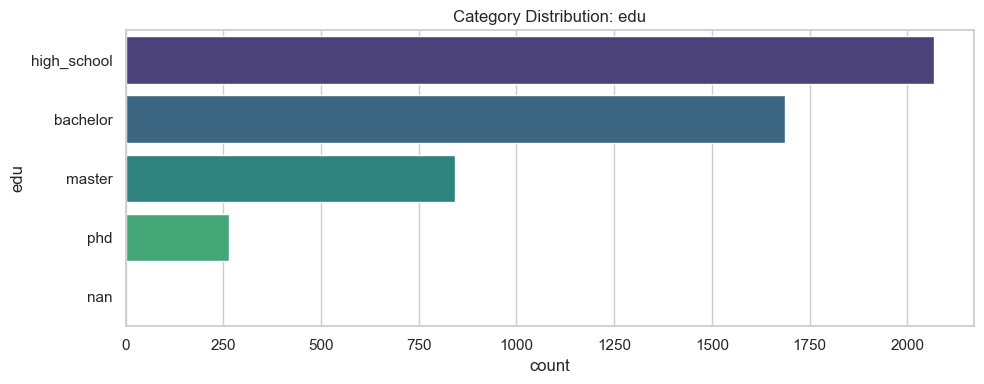

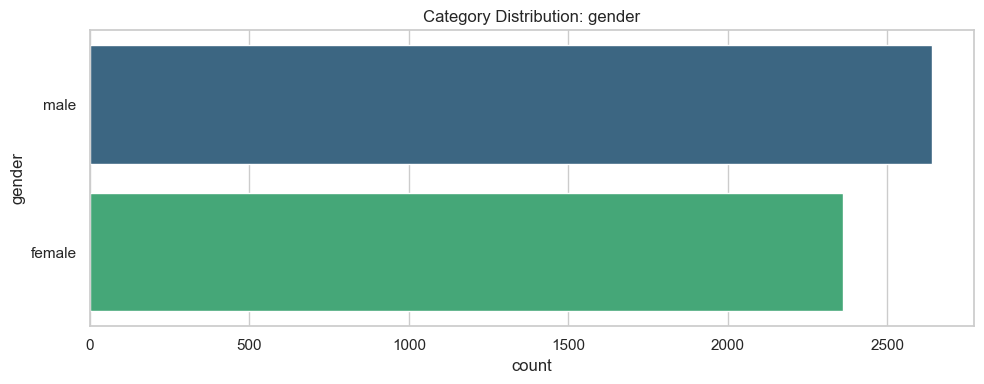

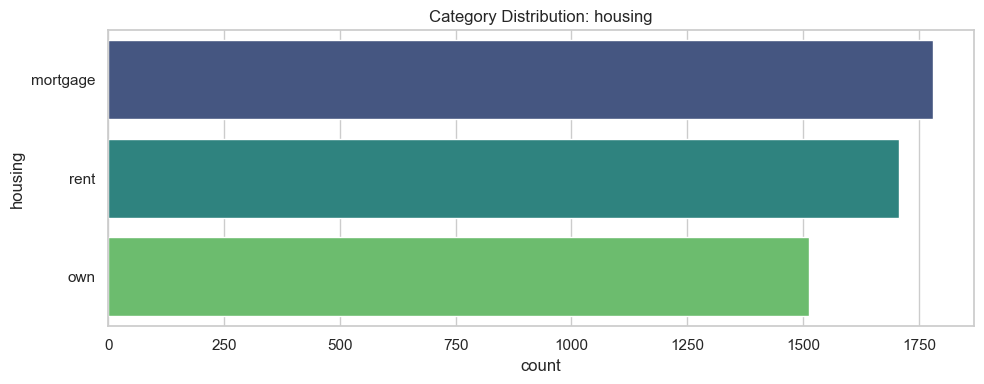

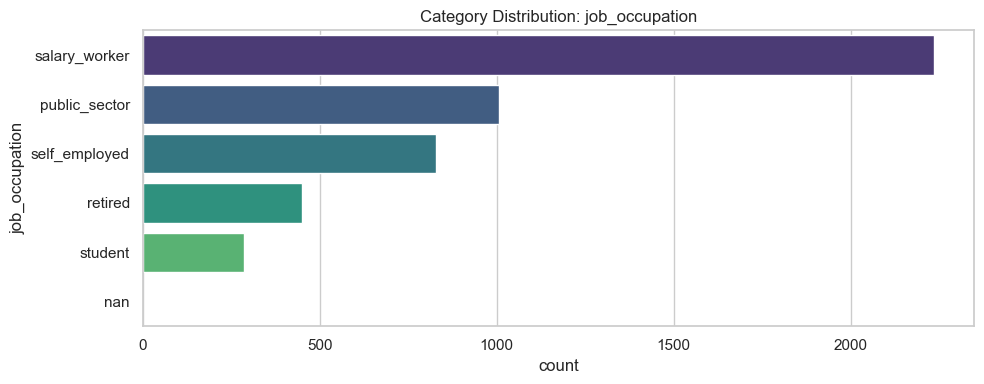

In [56]:
sample_cat = cat_cols[:10]  # adjust as needed

for col in sample_cat:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts(dropna=False).index[:15]
    sns.countplot(y=col, data=df, order=order, palette="viridis")
    plt.title(f"Category Distribution: {col}")
    plt.tight_layout()
    plt.show()

### Default rates by categorical feature

,n,default_rate
edu,,
high_school,2067,0.072569
bachelor,1688,0.062204
master,842,0.049881
phd,265,0.060377


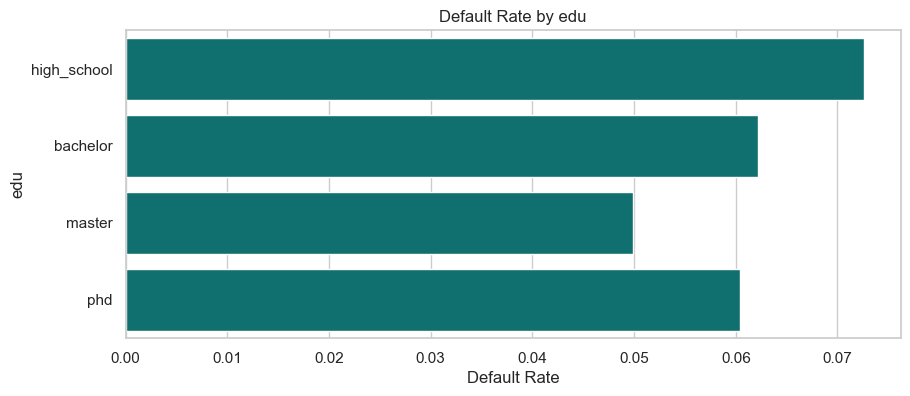

,n,default_rate
gender,,
male,2640,0.062879
female,2360,0.065254


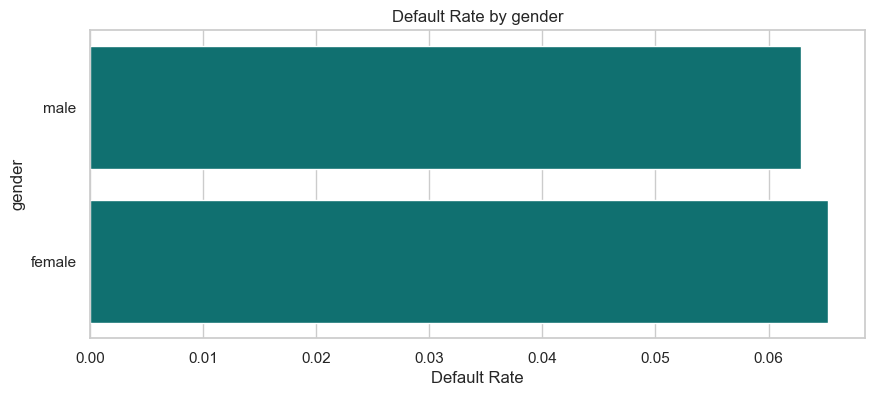

,n,default_rate
housing,,
mortgage,1780,0.065169
rent,1707,0.065026
own,1513,0.061467


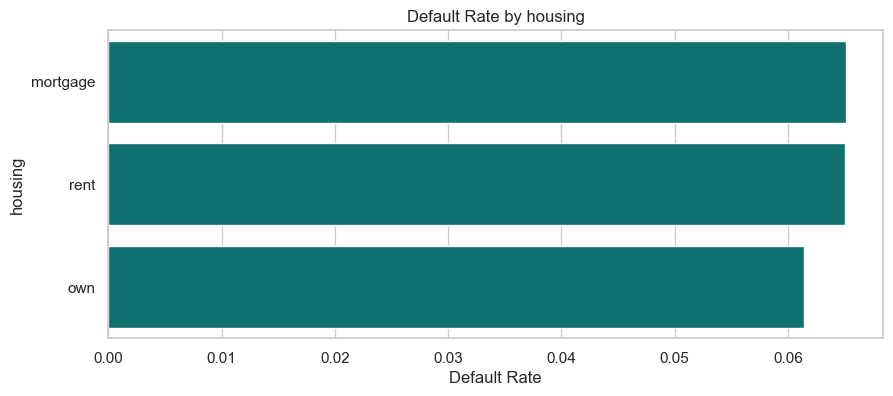

,n,default_rate
job_occupation,,
salary_worker,2237,0.063925
public_sector,1007,0.060576
self_employed,827,0.071342
retired,450,0.046667
student,285,0.091228


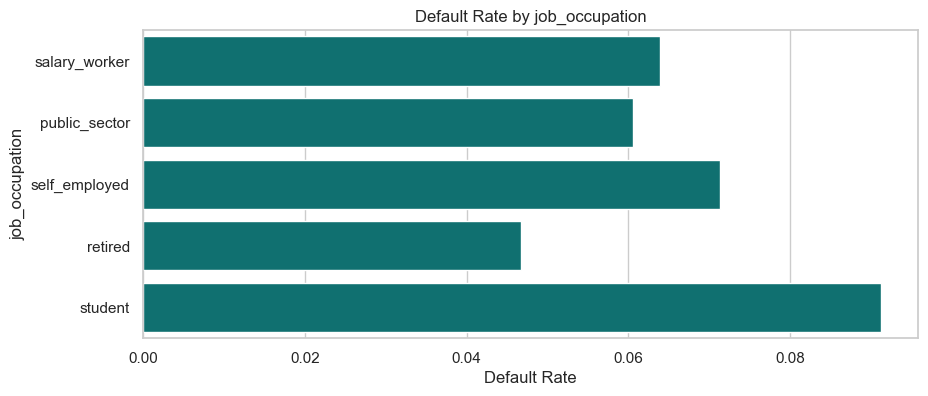

In [57]:
def default_rate_by_category(data, col, target=TARGET_COL, min_count=50):
    tmp = (
        data.groupby(col)[target]
            .agg(["count", "mean"])
            .rename(columns={"count": "n", "mean": "default_rate"})
            .sort_values("n", ascending=False)
    )
    return tmp[tmp["n"] >= min_count]

for col in sample_cat[:6]:
    dr = default_rate_by_category(df, col)
    display(dr)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=dr["default_rate"], y=dr.index, color="teal")
    plt.title(f"Default Rate by {col}")
    plt.xlabel("Default Rate")
    plt.ylabel(col)
    plt.show()

### Default rates by numeric bins

Numeric columns used for binning: ['age', 'income', 'past_bad_credit', 'married', 'loan_amount', 'debt_to_income', 'credit_history_years']


,bin,n,default_rate
0,"(20.999, 26.0]",598,0.070234
1,"(26.0, 30.0]",432,0.064815
2,"(30.0, 35.0]",480,0.056250
3,"(35.0, 40.0]",494,0.066802
4,"(40.0, 45.0]",526,0.058935
5,"(45.0, 50.0]",502,0.051793
6,"(50.0, 56.0]",535,0.059813
7,"(56.0, 60.0]",439,0.079727
8,"(60.0, 66.0]",558,0.069892
9,"(66.0, 70.0]",436,0.061927


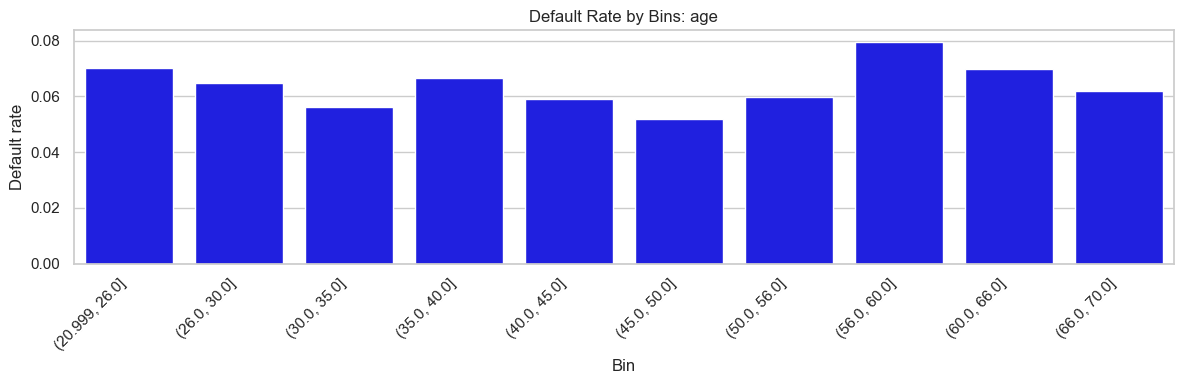

,bin,n,default_rate
0,"(4605.2789999999995, 13750.429]",477,0.092243
1,"(13750.429, 16959.928]",477,0.075472
2,"(16959.928, 19585.959]",477,0.056604
3,"(19585.959, 22102.432]",476,0.052521
4,"(22102.432, 24763.455]",477,0.069182
5,"(24763.455, 27947.13]",477,0.054507
6,"(27947.13, 31512.217]",476,0.069328
7,"(31512.217, 36245.992]",477,0.067086
8,"(36245.992, 44383.628]",477,0.079665
9,"(44383.628, 120615.52]",477,0.039832


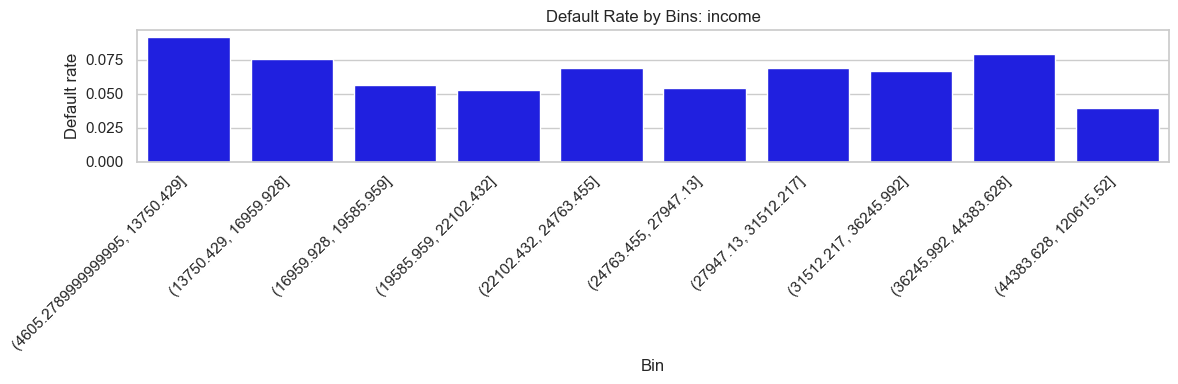

,bin,n,default_rate
0,"(1120.249, 3934.475]",500,0.072
1,"(3934.475, 5065.392]",500,0.042
2,"(5065.392, 6031.701]",500,0.082
3,"(6031.701, 6976.246]",500,0.046
4,"(6976.246, 8007.165]",500,0.056
5,"(8007.165, 9201.222]",500,0.072
6,"(9201.222, 10767.349]",500,0.066
7,"(10767.349, 12905.096]",500,0.036
8,"(12905.096, 16603.185]",500,0.094
9,"(16603.185, 91880.78]",500,0.074


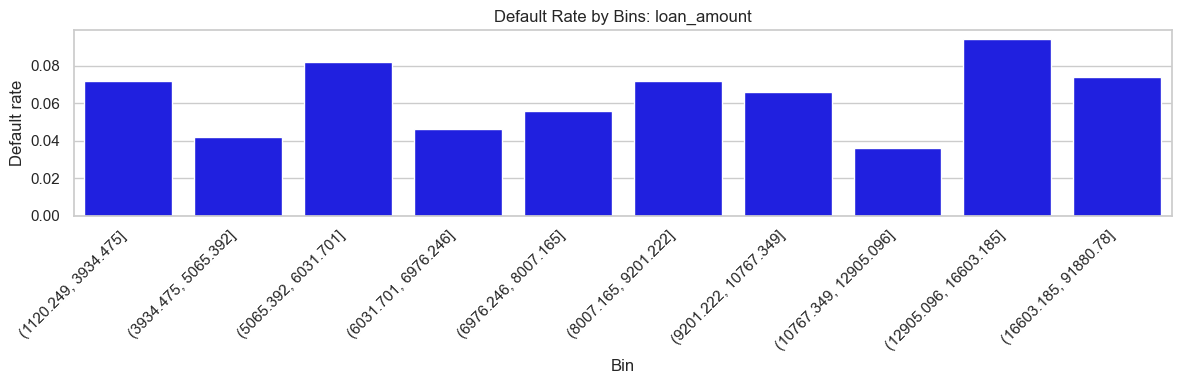

,bin,n,default_rate
0,"(0.009000000000000001, 0.12]",533,0.043152
1,"(0.12, 0.19]",471,0.044586
2,"(0.19, 0.25]",543,0.057090
3,"(0.25, 0.29]",423,0.056738
4,"(0.29, 0.34]",558,0.060932
5,"(0.34, 0.38]",425,0.054118
6,"(0.38, 0.43]",511,0.084149
7,"(0.43, 0.49]",494,0.089069
8,"(0.49, 0.56]",466,0.066524
9,"(0.56, 1.24]",475,0.086316


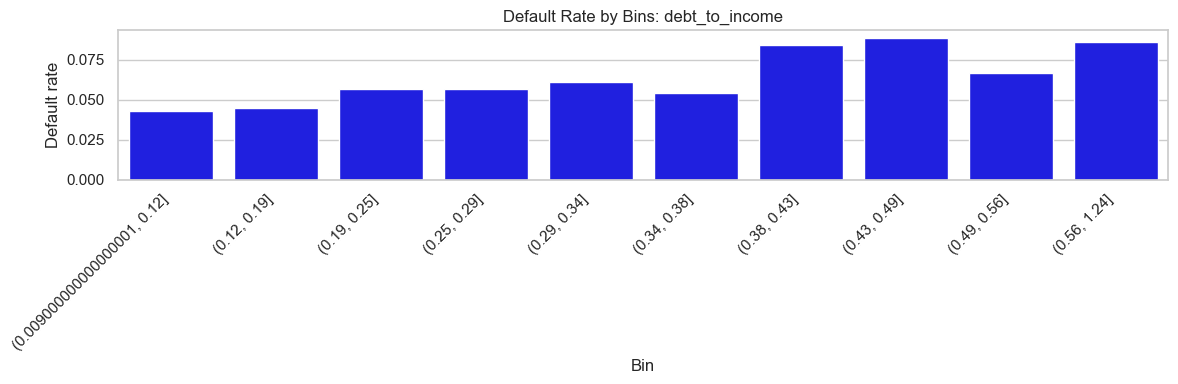

,bin,n,default_rate
0,"(-0.001, 2.4]",509,0.055010
1,"(2.4, 4.1]",478,0.094142
2,"(4.1, 5.3]",494,0.078947
3,"(5.3, 6.4]",493,0.068966
4,"(6.4, 7.4]",486,0.072016
5,"(7.4, 8.4]",481,0.064449
6,"(8.4, 9.4]",471,0.044586
7,"(9.4, 10.76]",470,0.040426
8,"(10.76, 12.5]",495,0.052525
9,"(12.5, 22.4]",476,0.077731


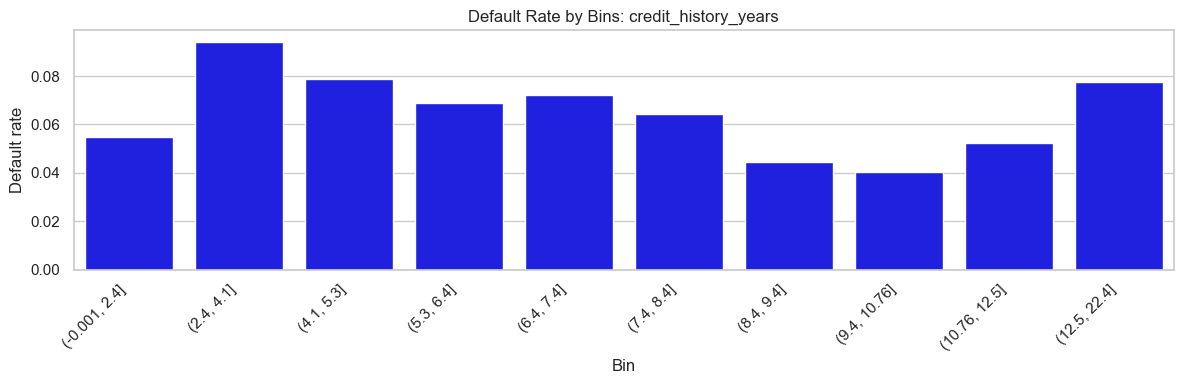

In [58]:
def binned_default_rate(data, col, target=TARGET_COL, q=10):
    temp = data[[col, target]].dropna().copy()

    if temp[col].nunique() < 5:
        return None

    temp["bin"] = pd.qcut(temp[col], q=min(q, temp[col].nunique()), duplicates="drop")
    out = temp.groupby("bin", observed=True)[target].agg(["count", "mean"]).reset_index()
    out.columns = ["bin", "n", "default_rate"]
    return out

# Recreate numeric feature list inside this cell so it never depends on earlier cells
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET_COL]

# Optional: inspect first
print("Numeric columns used for binning:", num_cols[:20])

for col in num_cols[:8]:
    res = binned_default_rate(df, col, target=TARGET_COL, q=10)
    if res is None:
        continue

    dr = res.copy()
    dr["bin"] = dr["bin"].astype(str)

    display(dr)

    plt.figure(figsize=(12, 4))
    sns.barplot(data=dr, x="bin", y="default_rate", color="blue")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Default Rate by Bins: {col}")
    plt.xlabel("Bin")
    plt.ylabel("Default rate")
    plt.tight_layout()
    plt.savefig(f"output/default_rate_{col}.png")
    plt.show()

#### Outlier detection

In [31]:
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        s = data[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append([col, len(s), n_out, n_out / len(s) if len(s) else np.nan, lower, upper])
    return pd.DataFrame(rows, columns=["feature", "n_nonmissing", "outlier_count", "outlier_pct", "lower_bound", "upper_bound"])

outlier_summary = iqr_outlier_summary(df, sample_num)
display(outlier_summary.sort_values("outlier_pct", ascending=False))

,feature,n_nonmissing,outlier_count,outlier_pct,lower_bound,upper_bound
2,past_bad_credit,5000,798,0.159600,0.00000,0.00000
4,loan_amount,5000,251,0.050200,-3507.40125,20728.00875
1,income,4768,153,0.032089,-5020.69125,56695.53875
6,credit_history_years,4853,23,0.004739,-3.25000,17.95000
5,debt_to_income,4899,12,0.002449,-0.14000,0.82000
0,age,5000,0,0.000000,-4.50000,95.50000
3,married,5000,0,0.000000,-1.50000,2.50000


### Outlier plots

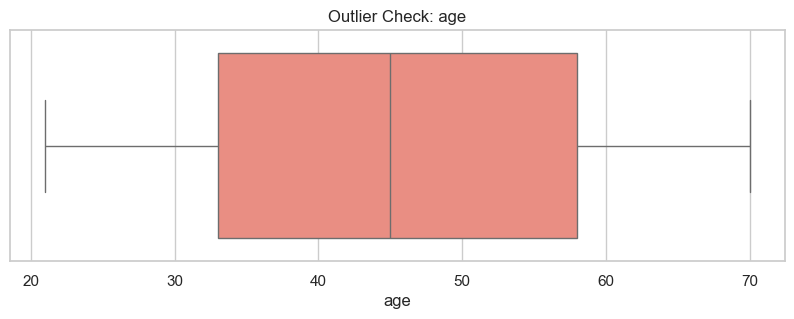

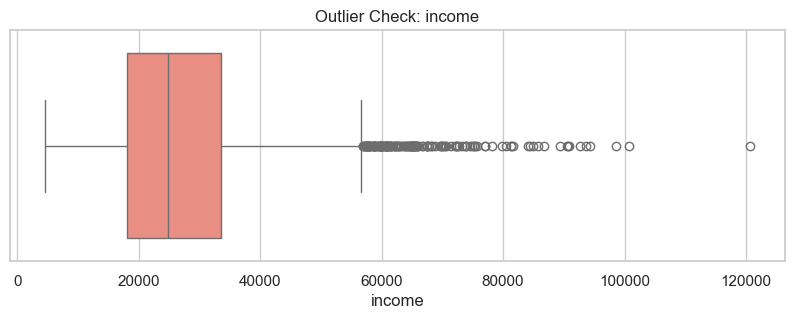

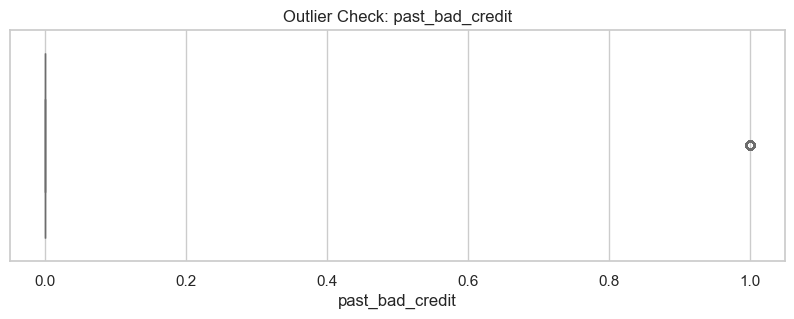

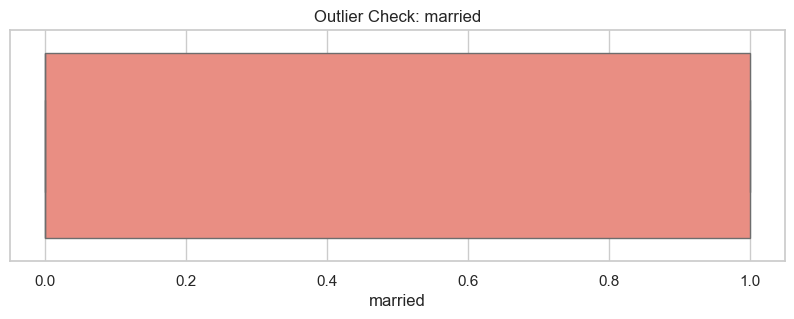

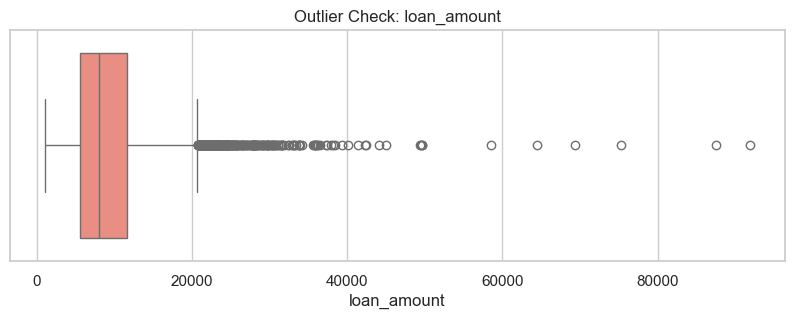

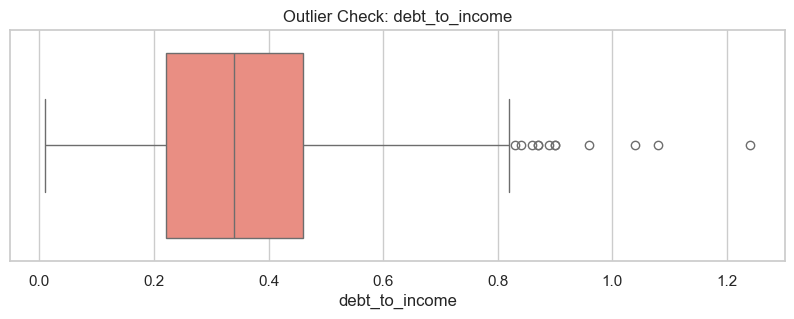

In [59]:
for col in sample_num[:6]:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df[col], color="salmon")
    plt.title(f"Outlier Check: {col}")
    plt.show()

### Feature engineering

In [60]:
df_fe = df.copy()

# Example: log transform skewed numeric variables
skewed_cols = []
for col in num_cols:
    s = df_fe[col].dropna()
    if len(s) > 0 and abs(s.skew()) > 1:
        skewed_cols.append(col)

for col in skewed_cols:
    new_col = f"log_{col}"
    df_fe[new_col] = np.log1p(df_fe[col].clip(lower=0))

print("Skewed columns transformed:", skewed_cols)

Skewed columns transformed: ['income', 'past_bad_credit', 'loan_amount']


#### Missingness flags

In [61]:
high_missing_cols = missing[missing["missing_pct"] > 20].index.tolist()

for col in high_missing_cols:
    df_fe[f"{col}_is_missing"] = df_fe[col].isna().astype(int)

print("Missingness flags created:", len(high_missing_cols))

Missingness flags created: 0


### Save outputs

In [62]:
os.makedirs("output", exist_ok=True)

df_fe.to_csv("output/credit_risk_eda_ready.csv", index=False)
audit.to_csv("output/column_audit.csv", index=False)
missing.to_csv("output/missing_summary.csv", index=True)
high_corr_df.to_csv("output/high_corr_pairs.csv", index=False)
outlier_summary.to_csv("output/outlier_summary.csv", index=False)

print("Saved files to output/")

Saved files to output/
